# 02 - Part B: locate a crop, then drive the camera until the circle is visible

> *"Given the reference image above, read an arbitrarily cropped part of the
> image and output the camera movements in steps until the circle is visible."*

Two sub-problems, and the second one is only well posed if the first one
succeeds:

1. **Where is this crop?** Answer it, *and* decide whether the answer is
   trustworthy. Some crops genuinely cannot be located (a patch of blank page; a
   strip of one straight border). For those the correct output is a report, not
   a guess.
2. **Which way to the circle?** Once the view is located, the path is a
   deterministic translation of the field of view.

Contents: the movement convention (and why it is exact) -> candidate approaches
-> localisation with identifiability tests -> scenarios -> a worked plan ->
statistics -> robustness -> optional closed-loop exploration -> limitations.

In [1]:
# --- Colab / local bootstrap -------------------------------------------------
# Works unchanged in Colab and on a local machine: walk up from the working
# directory until the package is found; in Colab, mount Drive first.
import os, sys

def _find_root(start=None):
    p = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(p, "src", "aulecv")):
            return p
        nxt = os.path.dirname(p)
        if nxt == p:
            return None
        p = nxt

PROJECT_ROOT = _find_root()
if PROJECT_ROOT is None and "google.colab" in sys.modules:      # pragma: no cover
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/AULE_ComputerVisionChallenge"
    if not os.path.isdir(os.path.join(PROJECT_ROOT, "src", "aulecv")):
        raise RuntimeError("put the project folder at " + PROJECT_ROOT)
if PROJECT_ROOT is None:
    raise RuntimeError("could not locate the project root")

os.environ["AULECV_PROJECT_ROOT"] = PROJECT_ROOT
if os.path.join(PROJECT_ROOT, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

import numpy as np, cv2, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

from aulecv import config as C, detect, rotation, navigation, camera, viz
from aulecv import io as aio

np.random.seed(C.RANDOM_SEED)
OUT = aio.ensure_output_dirs()
print("PROJECT_ROOT :", PROJECT_ROOT)
print("outputs      :", OUT)
print("python       :", sys.version.split()[0], "| opencv", cv2.__version__, "| numpy", np.__version__)

PROJECT_ROOT : D:\Aulespace\AULE_ComputerVisionChallenge
outputs      : D:\Aulespace\AULE_ComputerVisionChallenge\outputs
python       : 3.14.3 | opencv 4.13.0 | numpy 2.4.3


In [2]:
reference = aio.load_reference()
ref_det = detect.detect_port(reference)
sx, sy = navigation.pixels_per_cm(ref_det)
print("reference          :", reference.shape)
print("marker centre      :", np.round(ref_det.marker_center, 2),
      " radius {:.2f} px".format(ref_det.marker_radius_px))
print("raster scale       : {:.4f} px/cm in x, {:.4f} px/cm in y".format(sx, sy))
print("   (from the detected outer square = {:.1f} cm across)".format(C.OUTER_SIDE_CM))

reference          : (558, 604, 3)
marker centre      : [185.02 176.5 ]  radius 54.22 px
raster scale       : 13.7500 px/cm in x, 12.9500 px/cm in y
   (from the detected outer square = 40.0 cm across)


## 1. The movement convention - and why "slide a window" is physically exact

There is exactly **one** convention in this notebook:

> A command is a **translation of the camera parallel to the port plane**, in
> reference-image axes: `RIGHT = +x_img`, `DOWN = +y_img`.

This is not a convenience. Translating a pinhole camera by $t=(t_x,t_y,0)$ while
it keeps looking straight at a plane at depth $d$ induces the plane homography

$$ H = K\left(I + \frac{t\,n^\top}{d}\right)K^{-1}, \qquad n=(0,0,1) $$

Expanding, $I + t n^\top/d$ has $1$ on the diagonal, zeros below, and the column
$(t_x/d,\;t_y/d,\;1)$: conjugating by $K$ leaves a matrix whose only non-trivial
entries are the translation $-f\,t/d$. So a parallel translation is an **exact
pure image translation** -- the field of view really does just slide over the
reference image, with no warping at all.

Contrast this with a **pan/tilt**, which induces $H = K R K^{-1}$: a genuine
projective warp, not a window shift. Because of that, this module emits **no
pan/tilt angles**; the crop model would be wrong for them.

The window moves the same way as the camera; the *content* inside the window
appears to move the opposite way.

In [3]:
# Numerical check of the claim above, at this scene's scale.
f_demo = 1334.4
K_demo = camera.estimate_camera_intrinsics(f_demo, principal_point=(0.0, 0.0))

dC = np.array([3.0, -2.0, 0.0])      # the CAMERA moves 3 cm right, 2 cm up
# t = -R C, and R = I here, so the relative translation entering the plane
# homography is t_rel = t_new - t_ref = -dC.
t_rel = -dC
H_par = camera.plane_induced_homography(K_demo, np.eye(3), t_rel, (0, 0, 1),
                                        C.CAMERA_DISTANCE_CM)
H_par = H_par / H_par[2, 2]
print("camera translation dC (cm)   :", dC)
print("t_rel = -dC                  :", t_rel)
print("H for this motion:")
print(np.round(H_par, 8))
print()
print("linear part - I  (max abs)   : {:.3e}".format(np.abs(H_par[:2, :2] - np.eye(2)).max()))
print("bottom row - [0 0 1]         : {:.3e}".format(np.abs(H_par[2] - [0, 0, 1]).max()))
print("translation part (px)        :", np.round(H_par[:2, 2], 4))
print("expected  -f * dC / d  (px)  :", np.round(-f_demo * dC[:2] / C.CAMERA_DISTANCE_CM, 4))
print()
print("=> pure translation, exactly (no warping at all). The crop model is")
print("   physically correct for this motion.")
print("   The CONTENT shifts by {} px, i.e. opposite to the camera, which is the"
      .format(np.round(H_par[:2, 2], 1)))
print("   same statement as 'the field-of-view window slides WITH the camera'.")
print()
R_pan = camera.camera_pose_for_angle(8.0)["R"]
H_pan = K_demo @ R_pan @ np.linalg.inv(K_demo); H_pan = H_pan / H_pan[2, 2]
print("By contrast, an 8 deg PAN gives H = K R K^-1 with bottom row",
      np.round(H_pan[2], 6))
print("=> not a translation. No pan/tilt commands are emitted.")

camera translation dC (cm)   : [ 3. -2.  0.]
t_rel = -dC                  : [-3.  2. -0.]
H for this motion:
[[  1.      0.    -40.032]
 [  0.      1.     26.688]
 [  0.      0.      1.   ]]

linear part - I  (max abs)   : 0.000e+00
bottom row - [0 0 1]         : 0.000e+00
translation part (px)        : [-40.032  26.688]
expected  -f * dC / d  (px)  : [-40.032  26.688]

=> pure translation, exactly (no warping at all). The crop model is
   physically correct for this motion.
   The CONTENT shifts by [-40.   26.7] px, i.e. opposite to the camera, which is the
   same statement as 'the field-of-view window slides WITH the camera'.

By contrast, an 8 deg PAN gives H = K R K^-1 with bottom row [-0.0001  0.      1.    ]
=> not a translation. No pan/tilt commands are emitted.


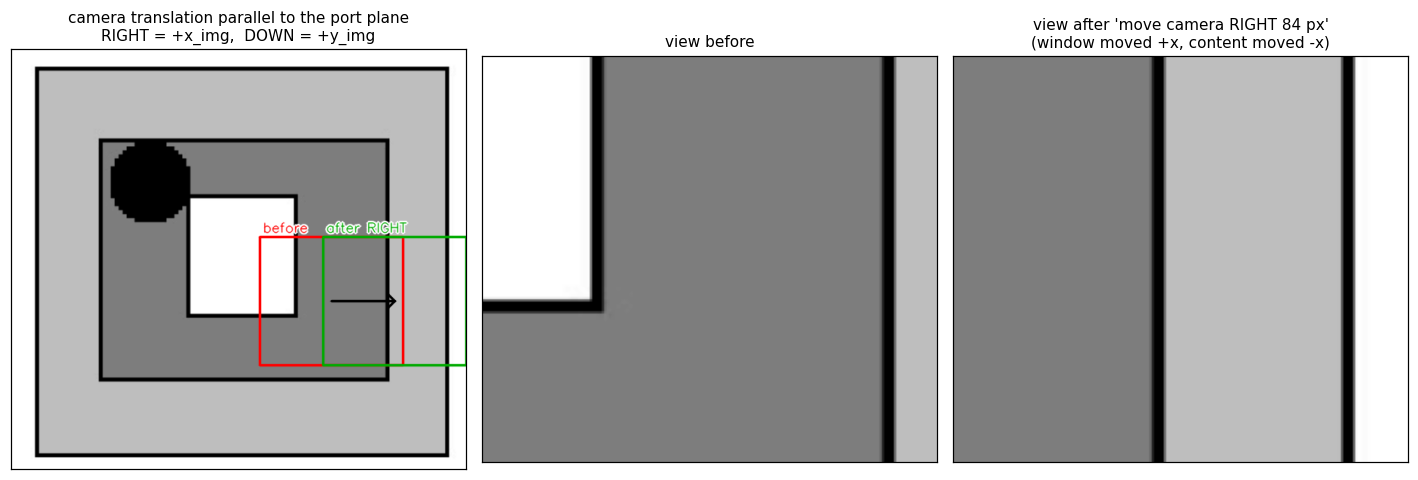

In [4]:
fig = viz.movement_convention_figure(reference, ref_det, (330, 250, 190, 170), shift_px=120)
fig.savefig(aio.output_path("crop_navigation", "movement_convention.png"),
            bbox_inches="tight", dpi=110)
plt.show()

## 2. Candidate approaches to localisation

| Approach | Verdict |
|---|---|
| Feature matching (ORB/SIFT) + homography | Rejected: this figure has four large flat regions and only ~12 genuine corners; descriptor matching is unreliable and, worse, *silently* unreliable. |
| Phase correlation | Rejected: designed for same-size images with cyclic shift; a small crop against a large reference needs padding and the peak is weak. |
| Cross-correlation of edge maps | Considered; slightly more robust to illumination but loses the flat-region evidence that actually disambiguates here. |
| **`matchTemplate` with `TM_CCOEFF_NORMED`** | **Chosen.** Mean- and contrast-normalised, exhaustive (so no local minimum), and its **score map is itself the uncertainty estimate** -- which is the part that matters. |

### The part that matters: is the answer identifiable?

`matchTemplate` always returns an argmax. The question is whether that argmax
means anything. Three tests, all scaled to the crop's own size:

1. **Texture** -- crop std below `CROP_MIN_STD` => `featureless`.
2. **Plateau extent (the aperture problem)** -- the connected set of scores
   within `MATCH_PLATEAU_TOL` of the peak must not span more than
   `MATCH_PLATEAU_MAX_FRAC` of the crop along either axis. A strip of one
   straight border slides freely along that border and fails on exactly one axis.
3. **Second peak** -- after suppressing a neighbourhood of the best match, a
   rival within `MATCH_SECOND_PEAK_RATIO` means the pattern repeats.

A non-`ok` status produces **no movement commands**.

## 3. Scenarios

Eight hand-chosen crops covering the cases the assignment implies: the marker
already visible; the marker to the left / right / above / below; partially
visible; an edge-only (aperture) strip; and a uniform patch.

In [5]:
m = np.round(ref_det.marker_center).astype(int)
r = int(round(ref_det.marker_radius_px))

SCENARIOS = [
    ("marker fully visible",     (m[0] - 110, m[1] - 100, 220, 200)),
    ("marker partially visible", (m[0] + 10,  m[1] - 40,  200, 180)),
    ("marker is up-left",        (400, 380, 200, 170)),
    ("marker is left",           (400, 150, 190, 180)),
    ("marker is above",          (120, 380, 200, 160)),
    ("marker is up-right",       (30,  400, 190, 150)),
    ("edge-only strip (aperture)", (200, 20, 120, 16)),
    ("uniform page patch",       (4, 4, 18, 18)),
]

rows, panels, titles = [], [], []
for name, win in SCENARIOS:
    crop = navigation.extract_crop(reference, *win)
    loc = navigation.localize_crop(crop, reference)
    plan = navigation.plan_crop_movements(loc, ref_det, reference.shape)
    rows.append({
        "scenario": name, "given_window": win,
        "status": loc.status,
        "found_at": (loc.x, loc.y) if loc.status == "ok" else None,
        "loc_error_px": (max(abs(loc.x - win[0]), abs(loc.y - win[1]))
                         if loc.status == "ok" else np.nan),
        "score": round(loc.score, 4) if np.isfinite(loc.score) else np.nan,
        "plateau_px": loc.plateau_extent_px,
        "plan_status": plan.status, "n_steps": plan.n_steps, "goal": plan.goal,
        "reason": loc.reasons[0][:70],
    })
    panels.append(crop); titles.append("{}\n{} / {}".format(name, loc.status, plan.status))

scen = pd.DataFrame(rows)
display(scen)
print("\ncrops that produced movement commands :",
      int((scen['n_steps'] > 0).sum()), "of", len(scen))
print("crops correctly refused               :",
      int((scen['status'] != 'ok').sum()))
print("max localisation error among 'ok'     : {:.0f} px"
      .format(np.nanmax(scen['loc_error_px'])))

,scenario,given_window,status,found_at,loc_error_px,score,plateau_px,plan_status,n_steps,goal,reason
0,marker fully visible,"(75, 76, 220, 200)",ok,"(75, 76)",0.0,1.0,"(3, 3)",already_visible,0,full_disk,"unique, sharply-peaked match"
1,marker partially visible,"(195, 136, 200, 180)",ok,"(195, 136)",0.0,1.0,"(3, 3)",ok,11,full_disk,"unique, sharply-peaked match"
2,marker is up-left,"(400, 380, 200, 170)",ok,"(400, 380)",0.0,1.0,"(1, 1)",ok,65,full_disk,"unique, sharply-peaked match"
3,marker is left,"(400, 150, 190, 180)",ambiguous,None,NaN,1.0,"(1, 137)",ambiguous,0,,score plateau spans 1x137 px (limit 48x45); th...
4,marker is above,"(120, 380, 200, 160)",ambiguous,None,NaN,1.0,"(183, 1)",ambiguous,0,,score plateau spans 183x1 px (limit 50x40); th...
5,marker is up-right,"(30, 400, 190, 150)",ok,"(30, 400)",0.0,1.0,"(1, 1)",ok,42,full_disk,"unique, sharply-peaked match"
6,edge-only strip (aperture),"(200, 20, 120, 16)",ambiguous,None,NaN,1.0,"(427, 1)",ambiguous,0,,score plateau spans 427x1 px (limit 30x4); the...
7,uniform page patch,"(4, 4, 18, 18)",featureless,None,NaN,NaN,"(0, 0)",featureless,0,,crop grey-level std 0.00 < 3.00: no structure ...



crops that produced movement commands : 3 of 8
crops correctly refused               : 4
max localisation error among 'ok'     : 0 px


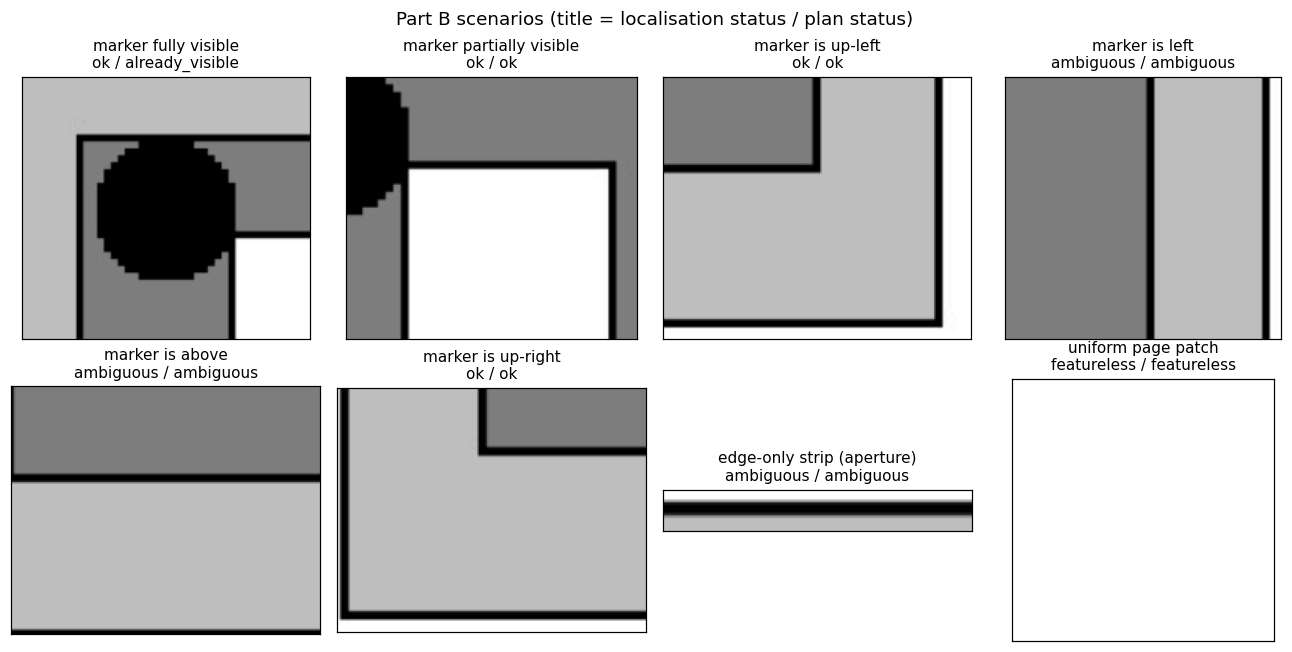

In [6]:
fig = viz.grid(panels, titles, cols=4, figsize_per=3.0,
               suptitle="Part B scenarios (title = localisation status / plan status)")
fig.savefig(aio.output_path("crop_navigation", "scenarios.png"), bbox_inches="tight", dpi=110)
plt.show()

Note the two refusals at the end. The edge-only strip is flagged because its
score plateau stretches hundreds of pixels along the border it sits on -- the
classic aperture problem -- and because the same strip matches the other three
borders equally well. The uniform patch is flagged before matching even starts.
Neither produces a movement command, which is the honest answer.

## 4. A worked plan

Goal: the **whole marker disk** inside the view, with a margin of
`NAV_MARKER_MARGIN_FRAC` of its radius. If the view is too small to ever contain
the whole disk, the goal automatically relaxes to "the marker centre is in view".

Step size is `NAV_STEP_FRAC` (5%) of the crop's **smaller** side -- relative to
the view, not an absolute pixel count. Moves are 4-connected (one axis at a
time), dominant axis first.

In [7]:
WIN = (400, 380, 200, 170)
crop = navigation.extract_crop(reference, *WIN)
loc = navigation.localize_crop(crop, reference)
plan = navigation.plan_crop_movements(loc, ref_det, reference.shape)

print("localisation")
print("  status            :", loc.status)
print("  found at          :", (loc.x, loc.y), " (true {})".format(WIN[:2]))
print("  peak score        : {:.6f}".format(loc.score))
print("  second peak       : {:.6f}  (ratio {:.4f})".format(loc.second_peak, loc.second_peak_ratio))
print("  plateau extent    : {} px".format(loc.plateau_extent_px))
print("  per-axis uncert.  : {} px".format(tuple(round(v, 2) for v in loc.uncertainty_px)))
print("  reason            :", loc.reasons[0])
print()
print("plan")
print("  status            :", plan.status)
print("  goal              :", plan.goal)
print("  start window      :", plan.start_window)
print("  target window     :", plan.target_window)
print("  step size         : {:.1f} px".format(plan.step_px))
print("  total translation : dx {:+.1f} px ({:+.2f} cm),  dy {:+.1f} px ({:+.2f} cm)"
      .format(plan.total_px[0], plan.total_cm[0], plan.total_px[1], plan.total_cm[1]))
print("  steps issued      : {}   (optimal ceil(d/step) = {})".format(plan.n_steps, plan.optimal_steps))
print("  note              :", plan.reasons[0])
print()
print("first 5 and last 5 commands:")
for cmd in plan.commands[:5]:
    print("  " + cmd.describe())
print("  ...")
for cmd in plan.commands[-5:]:
    print("  " + cmd.describe())

localisation
  status            : ok
  found at          : (400, 380)  (true (400, 380))
  peak score        : 0.999999
  second peak       : 0.686721  (ratio 0.6867)
  plateau extent    : (1, 1) px
  per-axis uncert.  : (0.0, 0.0) px
  reason            : unique, sharply-peaked match

plan
  status            : ok
  goal              : full_disk
  start window      : (400, 380, 200, 170)
  target window     : (125, 116, 200, 170)
  step size         : 8.5 px
  total translation : dx -275.0 px (-20.00 cm),  dy -264.0 px (-20.39 cm)
  steps issued      : 65   (optimal ceil(d/step) = 65)
  note              : camera translation parallel to the port plane, under the frontal pinhole model

first 5 and last 5 commands:
  step   1: move camera LEFT     8.5 px  ( 0.62 cm)  -> window (x= 392, y= 380)
  step   2: move camera LEFT     8.5 px  ( 0.62 cm)  -> window (x= 383, y= 380)
  step   3: move camera LEFT     8.5 px  ( 0.62 cm)  -> window (x= 374, y= 380)
  step   4: move camera LEFT     8.

In [8]:
frames = navigation.simulate_crop_navigation(reference, plan)
final_win = frames[-1]["window"]
print("final window            :", final_win)
print("marker fully visible?   :", navigation.marker_visible(final_win, ref_det, plan.goal))
print("frames rendered         :", len(frames), "(each cut fresh from the reference)")

cmds = pd.DataFrame([{"step": c.step, "direction": c.direction,
                      "dx_px": c.dx_px, "dy_px": c.dy_px,
                      "distance_px": c.distance_px, "distance_cm": round(c.distance_cm, 4),
                      "window_x": c.window_after[0], "window_y": c.window_after[1]}
                     for c in plan.commands])
cmds.to_csv(aio.output_path("crop_navigation", "commands.csv"), index=False)
display(cmds.head(8))

final window            : (125, 116, 200, 170)
marker fully visible?   : True
frames rendered         : 66 (each cut fresh from the reference)


,step,direction,dx_px,dy_px,distance_px,distance_cm,window_x,window_y
0,1,LEFT,-8.5,0.0,8.5,0.6182,392,380
1,2,LEFT,-8.5,0.0,8.5,0.6182,383,380
2,3,LEFT,-8.5,0.0,8.5,0.6182,374,380
3,4,LEFT,-8.5,0.0,8.5,0.6182,366,380
4,5,LEFT,-8.5,0.0,8.5,0.6182,358,380
5,6,LEFT,-8.5,0.0,8.5,0.6182,349,380
6,7,LEFT,-8.5,0.0,8.5,0.6182,340,380
7,8,LEFT,-8.5,0.0,8.5,0.6182,332,380


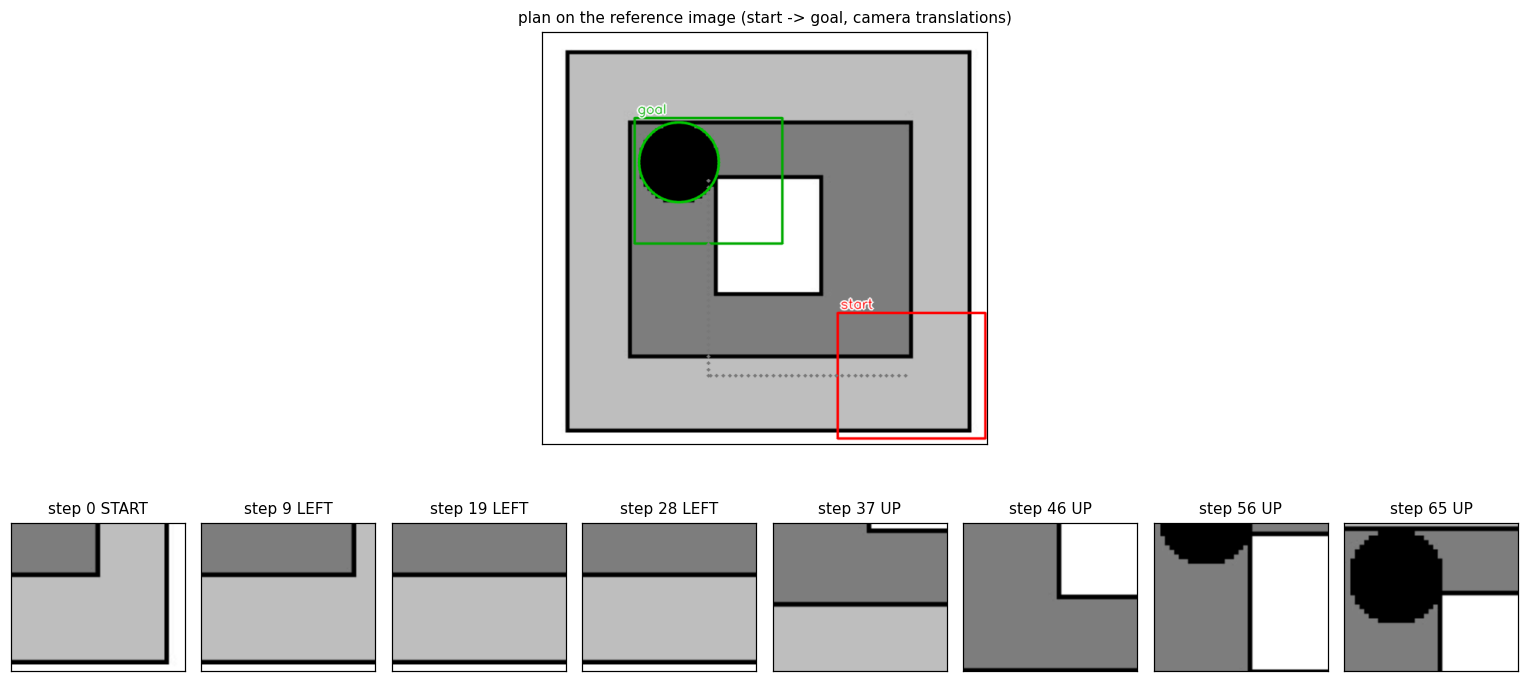

In [9]:
fig = viz.navigation_figure(reference, ref_det, plan, max_panels=8)
fig.savefig(aio.output_path("crop_navigation", "plan_overview.png"),
            bbox_inches="tight", dpi=110)
plt.show()

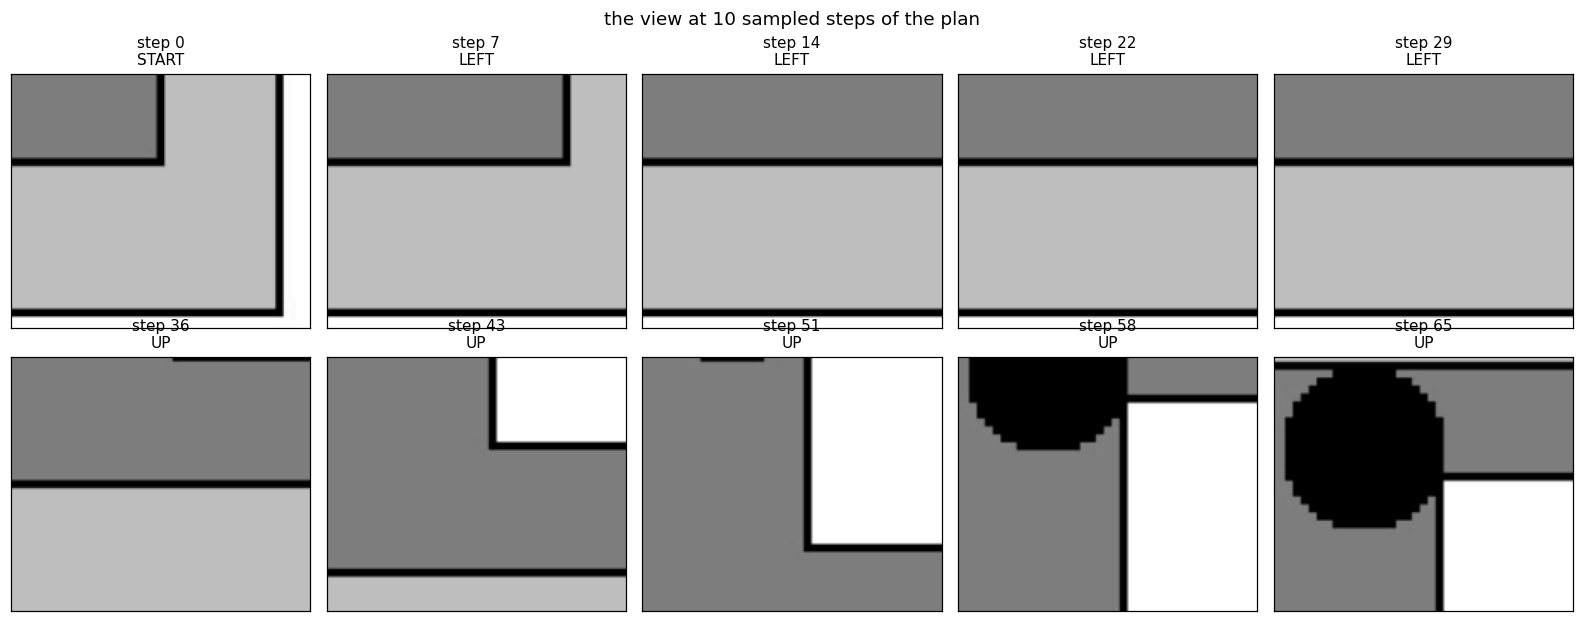

wrote 10 sampled frames to outputs/crop_navigation/


In [10]:
# Save a strip of the actual views along the way.
idx = np.unique(np.linspace(0, len(frames) - 1, 10).round().astype(int))
fig = viz.frame_strip([frames[i]["image"] for i in idx],
                      ["step {}\n{}".format(frames[i]["step"], frames[i]["direction"]) for i in idx],
                      cols=5, suptitle="the view at 10 sampled steps of the plan")
fig.savefig(aio.output_path("crop_navigation", "frames.png"), bbox_inches="tight", dpi=110)
plt.show()
for i in idx:
    aio.save_image(aio.output_path("crop_navigation", "frame_{:03d}.png".format(frames[i]["step"])),
                   frames[i]["image"])
print("wrote {} sampled frames to outputs/crop_navigation/".format(len(idx)))

## 5. Statistics over 300 random crops

In [11]:
rng = np.random.default_rng(C.RANDOM_SEED)
H, W = reference.shape[:2]
rows = []
for _ in range(300):
    w = int(rng.integers(60, 260)); h = int(rng.integers(60, 260))
    x = int(rng.integers(0, W - w)); y = int(rng.integers(0, H - h))
    loc = navigation.localize_crop(navigation.extract_crop(reference, x, y, w, h), reference)
    plan = navigation.plan_crop_movements(loc, ref_det, reference.shape)
    ok = loc.status == "ok"
    err = max(abs(loc.x - x), abs(loc.y - y)) if ok else np.nan
    reached = None
    if plan.status == "ok":
        reached = navigation.marker_visible(plan.commands[-1].window_after, ref_det, plan.goal)
    elif plan.status == "already_visible":
        reached = True
    rows.append({"x": x, "y": y, "w": w, "h": h, "crop_std": round(loc.crop_std, 3),
                 "status": loc.status, "loc_err_px": err,
                 "score": loc.score, "plan_status": plan.status,
                 "n_steps": plan.n_steps, "optimal_steps": plan.optimal_steps,
                 "goal_reached": reached})
rand = pd.DataFrame(rows)

n = len(rand)
ok = rand[rand["status"] == "ok"]
print("300 seeded random crops")
print("  status ok           : {:3d}  ({:.1%})".format(len(ok), len(ok) / n))
print("  status ambiguous    : {:3d}  ({:.1%})".format(int((rand['status'] == 'ambiguous').sum()),
                                                       (rand['status'] == 'ambiguous').mean()))
print("  status featureless  : {:3d}  ({:.1%})".format(int((rand['status'] == 'featureless').sum()),
                                                       (rand['status'] == 'featureless').mean()))
print()
print("  localisation error among 'ok' crops:")
print("     max  {:.0f} px     mean {:.4f} px     exact (0 px) {:.1%}"
      .format(ok['loc_err_px'].max(), ok['loc_err_px'].mean(), (ok['loc_err_px'] == 0).mean()))
print("  TARGET (stated in the plan): exact crops localised to within 1 px when status is ok.")
print("  MEASURED: {:.1%} of 'ok' crops within 1 px."
      .format((ok['loc_err_px'] <= 1).mean()))
print()
planned = rand[rand["plan_status"].isin(["ok", "already_visible"])]
print("  crops that produced a plan      : {} ({:.1%})".format(len(planned), len(planned) / n))
print("  of those, goal actually reached : {}/{}".format(int(planned['goal_reached'].sum()), len(planned)))
print("  steps issued == optimal ceil(d/step) for every plan:",
      bool((rand[rand['plan_status'] == 'ok']['n_steps']
            == rand[rand['plan_status'] == 'ok']['optimal_steps']).all()))
print()
print("  no crop with status != 'ok' produced commands:",
      bool((rand[rand['status'] != 'ok']['n_steps'] == 0).all()))

300 seeded random crops
  status ok           : 203  (67.7%)
  status ambiguous    :  89  (29.7%)
  status featureless  :   8  (2.7%)

  localisation error among 'ok' crops:
     max  2 px     mean 0.0099 px     exact (0 px) 99.5%
  TARGET (stated in the plan): exact crops localised to within 1 px when status is ok.
  MEASURED: 99.5% of 'ok' crops within 1 px.

  crops that produced a plan      : 203 (67.7%)
  of those, goal actually reached : 203/203
  steps issued == optimal ceil(d/step) for every plan: True

  no crop with status != 'ok' produced commands: True


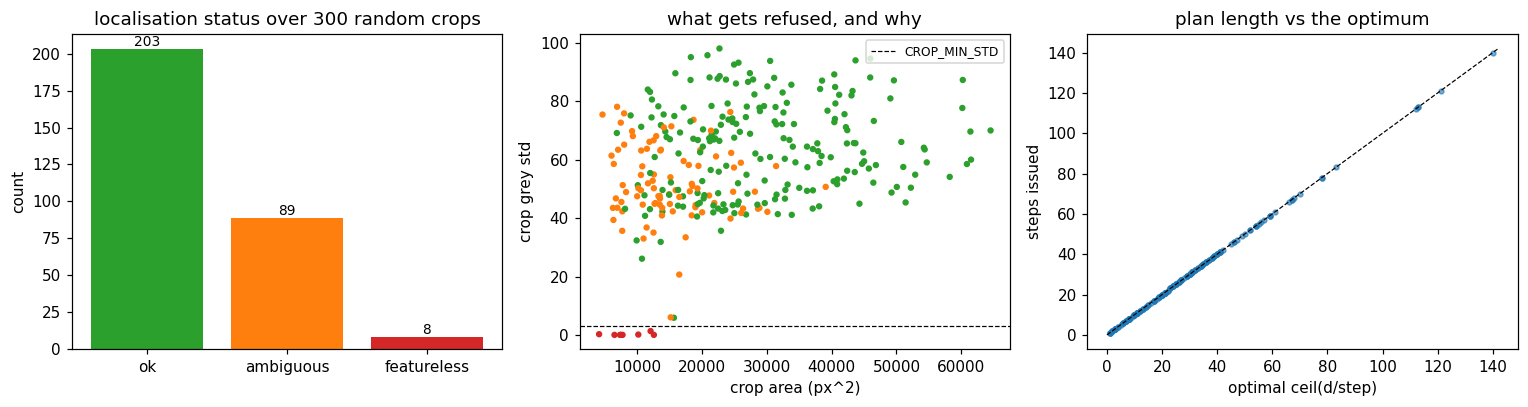

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
order = ["ok", "ambiguous", "featureless"]
counts = [int((rand["status"] == s).sum()) for s in order]
axes[0].bar(order, counts, color=["tab:green", "tab:orange", "tab:red"])
for i, v in enumerate(counts):
    axes[0].text(i, v + 2, str(v), ha="center", fontsize=9)
axes[0].set_title("localisation status over 300 random crops"); axes[0].set_ylabel("count")

axes[1].scatter(rand["w"] * rand["h"], rand["crop_std"],
                c=[{"ok": "tab:green", "ambiguous": "tab:orange",
                    "featureless": "tab:red"}[s] for s in rand["status"]], s=10)
axes[1].axhline(C.CROP_MIN_STD, color="k", ls="--", lw=0.8, label="CROP_MIN_STD")
axes[1].set_xlabel("crop area (px^2)"); axes[1].set_ylabel("crop grey std")
axes[1].set_title("what gets refused, and why"); axes[1].legend(fontsize=8)

pl = rand[rand["plan_status"] == "ok"]
axes[2].scatter(pl["optimal_steps"], pl["n_steps"], s=10, alpha=0.6)
lim = [0, max(1, int(pl["optimal_steps"].max()) + 2)]
axes[2].plot(lim, lim, "k--", lw=0.8)
axes[2].set_xlabel("optimal ceil(d/step)"); axes[2].set_ylabel("steps issued")
axes[2].set_title("plan length vs the optimum")
fig.tight_layout()
fig.savefig(aio.output_path("crop_navigation", "statistics.png"), bbox_inches="tight", dpi=110)
plt.show()

## 6. Noise robustness

In [13]:
rng = np.random.default_rng(C.RANDOM_SEED + 3)
rows = []
BASE = [(400, 380, 200, 170), (120, 110, 180, 180), (330, 250, 160, 150), (90, 400, 200, 140)]
for sigma in (0.0, 3.0, 6.0, 12.0, 20.0, 30.0):
    errs, statuses = [], []
    for (x, y, w, h) in BASE:
        crop = navigation.extract_crop(reference, x, y, w, h).astype(np.float32)
        if sigma > 0:
            crop = crop + rng.normal(0, sigma, crop.shape)
        crop = np.clip(crop, 0, 255).astype(np.uint8)
        loc = navigation.localize_crop(crop, reference)
        statuses.append(loc.status)
        if loc.status == "ok":
            errs.append(max(abs(loc.x - x), abs(loc.y - y)))
    rows.append({"noise_sigma": sigma, "n": len(BASE),
                 "n_ok": statuses.count("ok"),
                 "max_err_px": max(errs) if errs else np.nan,
                 "mean_err_px": float(np.mean(errs)) if errs else np.nan})
noise = pd.DataFrame(rows)
display(noise)
print("localisation stays exact up to sigma = {:.0f} grey levels"
      .format(float(noise[noise['max_err_px'] == 0]['noise_sigma'].max())))

,noise_sigma,n,n_ok,max_err_px,mean_err_px
0,0.0,4,4,0,0.0
1,3.0,4,4,0,0.0
2,6.0,4,4,0,0.0
3,12.0,4,4,0,0.0
4,20.0,4,4,0,0.0
5,30.0,4,4,0,0.0


localisation stays exact up to sigma = 30 grey levels


## 7. OPTIONAL extension - closed-loop exploration

**Not part of the Part B deliverable.** The assignment asks for movement commands
*given a crop*; when the crop cannot be located the honest answer is the report
in section 3, and that is what the core pipeline returns.

This section shows what an agent could do *instead of stopping*: walk an outward
square spiral, re-localising the live view at every stop, and switch to the
deterministic plan the moment the view becomes identifiable. It is included for
completeness and clearly separated from the answer.

In [14]:
START = (500, 250, 90, 90)          # a flat-ish patch the core cannot pin down
base_loc = navigation.localize_crop(navigation.extract_crop(reference, *START), reference)
print("core pipeline on this view :", base_loc.status, "->",
      navigation.plan_crop_movements(base_loc, ref_det, reference.shape).n_steps, "commands")
print()
out = navigation.explore_until_localized(reference, ref_det, START)
print("OPTIONAL exploration status :", out["status"])
print("search stride               : {:.0f} px ({:.0%} of the view's larger side)"
      .format(out["step_px"], C.EXPLORE_STEP_FRAC))
print("exploration steps taken     :", out["steps_explored"])
print("window when identifiable    :", out["window"])
if out["plan"] is not None:
    print("follow-up plan              :", out["plan"].status, out["plan"].n_steps, "steps")
print("trail length                :", len(out["trail"]), "stops")
print()
# ...and a case where even exploring does not help, to keep the claim honest.
HOPELESS = (200, 20, 120, 16)
out2 = navigation.explore_until_localized(reference, ref_det, HOPELESS)
print("the 120x16 edge strip of section 3, explored:", out2["status"],
      "after", out2["steps_explored"], "moves")
print("  a 16 px tall strip looks the same all along every border, so no amount")
print("  of translation at this view size makes it identifiable. Exploration is")
print("  a heuristic, not a guarantee.")

core pipeline on this view : ambiguous -> 0 commands



OPTIONAL exploration status : localized
search stride               : 45 px (50% of the view's larger side)
exploration steps taken     : 15
window when identifiable    : (334, 340, 90, 90)
follow-up plan              : ok 71 steps
trail length                : 16 stops



the 120x16 edge strip of section 3, explored: exhausted after 400 moves
  a 16 px tall strip looks the same all along every border, so no amount
  of translation at this view size makes it identifiable. Exploration is
  a heuristic, not a guarantee.


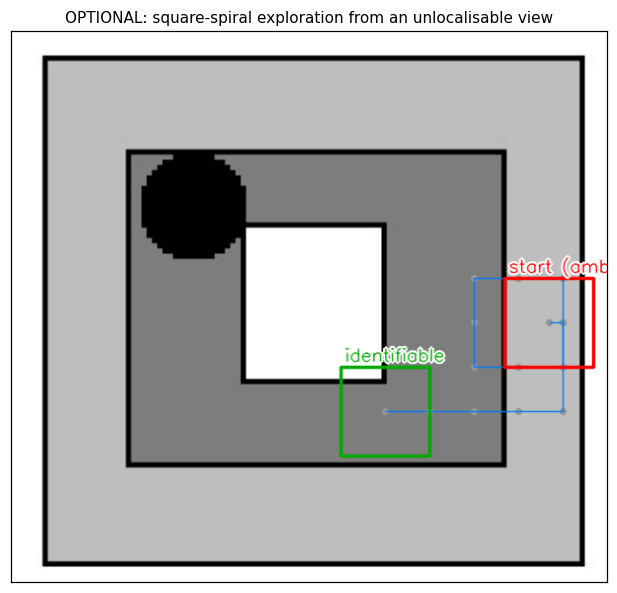

In [15]:
board = reference.copy()
trail = out["trail"]
w, h = START[2], START[3]
for (tx, ty) in trail:
    cv2.circle(board, (tx + w // 2, ty + h // 2), 3, (150, 150, 150), -1, cv2.LINE_AA)
for a, b in zip(trail, trail[1:]):
    cv2.line(board, (a[0] + w // 2, a[1] + h // 2), (b[0] + w // 2, b[1] + h // 2),
             (255, 120, 0), 1, cv2.LINE_AA)
board = viz.draw_window(board, START, (0, 0, 255), label="start (ambiguous)")
board = viz.draw_window(board, out["window"], (0, 170, 0), label="identifiable")
viz.show(board, "OPTIONAL: square-spiral exploration from an unlocalisable view", figsize=(7, 6.5))
plt.savefig(aio.output_path("crop_navigation", "optional_exploration.png"),
            bbox_inches="tight", dpi=110)
plt.show()

In [16]:
scen.to_csv(aio.output_path("crop_navigation", "scenarios.csv"), index=False)
rand.to_csv(aio.output_path("crop_navigation_results.csv"), index=False)
noise.to_csv(aio.output_path("crop_navigation", "noise_robustness.csv"), index=False)
print("wrote outputs/crop_navigation_results.csv and 4 files under outputs/crop_navigation/")

wrote outputs/crop_navigation_results.csv and 4 files under outputs/crop_navigation/


## 8. Limitations

* **Ambiguous crops cannot be localised, full stop.** A strip of one straight
  border, or a patch of uniform fill, does not determine a position -- no
  algorithm can recover what is not in the data. The pipeline says so instead of
  guessing; the optional spiral is the only way out, and it needs the camera to
  actually move.
* **Translation only.** Commands are translations parallel to the port plane.
  Rotation about the optical axis, change of distance, and pan/tilt are all out
  of scope here, and pan/tilt in particular would break the crop model.
* **Same-scale assumption.** `matchTemplate` is not scale invariant, so the crop
  must come from the reference at the same resolution. A multi-scale pyramid
  would lift that, at the cost of more false plateaus.
* **The cm figures assume the frontal pinhole model** and the per-axis raster
  scale (`px/cm` from the detected outer square). Because the drawing is
  schematic, the x and y scales differ slightly -- both are reported.
* **The goal is geometric**, "the marker disk is inside the window". It does not
  check that the marker is *recognisable* there (e.g. at very low resolution).